<a href="https://colab.research.google.com/github/ezenio01YT/PRA3024-notebook/blob/main/LHCb_2026_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome to Week 3!

We will be focussing in Particle Physics Analysis and detecting matter/antimatter assymetries in the production of certain types of particles.


![LHCb detector](https://www1b.physik.rwth-aachen.de/~schael/LHCb_files/LHCB%20PREVIEW-white-bg.jpg)

The data we are using comes from LHCb - one of the experiments at LHC. It is a highly specialised detector aimed at detecting decays involving the B-quark. Unlike the other major experiments, LHCb detects particles very close to the source and looks almost exclusively in the forward direction - this gives the detector many advantages compared to other experiments at LHC.

In order to get started, we need to access the [ROOT framework](https://root.cern.ch/) through a python package for that - [upROOT](https://pypi.org/project/uproot/) and download some datafiles into your environment!.

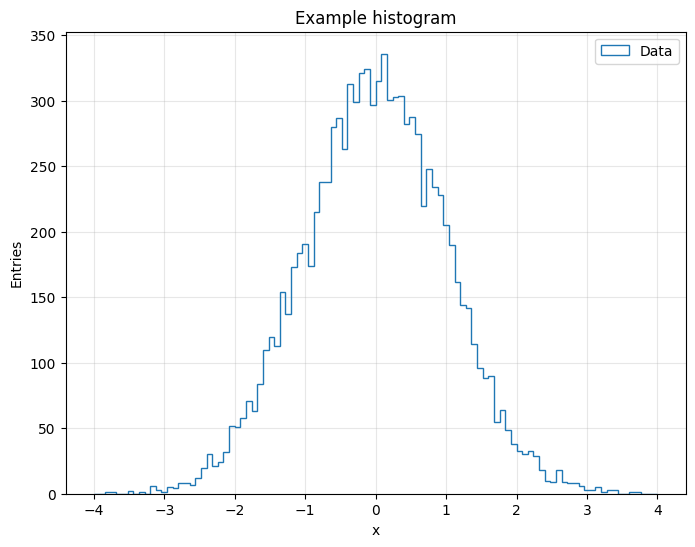

In [ ]:
# We use NumPy for numerical work and random numbers
# Matplotlib is used for plotting as before
import numpy as np
import matplotlib.pyplot as plt

# SciPy provides fitting tools, similar to ROOT's Fit("gaus")
from scipy.stats import norm


# ------------------------------------------------------------
# 1. Generate Gaussian-distributed random numbers
#    (equivalent to h.FillRandom("gaus"))
# ------------------------------------------------------------

# Mean (mu) and standard deviation (sigma) of the Gaussian
mu = 0.0
sigma = 1.0

# Number of entries to generate (like number of fills)
n_entries = 10000

# Generate random data
data = np.random.normal(loc=mu, scale=sigma, size=n_entries)


# ------------------------------------------------------------
# 2. Create a histogram (We will do this alot today...))
# ------------------------------------------------------------

# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -4, 4

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)


# ------------------------------------------------------------
# 3. Labels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot
plt.show()



All being well - this should give no errors and we should have some kind of Gaussian distribution above.

We now want to do two things, install uproot - and get our data file from the CERN open data storage location.

This will probably be ratelimited very quickly, so you can find it on Canvas here: https://canvas.maastrichtuniversity.nl/courses/26553/files/6101104?module_item_id=1009080

Then upload it directly.

In [ ]:
!pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.8/393.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 40.9 MB/s eta 0:00:00


In [ ]:
!mkdir LHCb_Data && cd LHCb_Data && wget http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root

mkdir: cannot create directory ‘LHCb_Data’: File exists


In [ ]:
import uproot

# Open the ROOT file
file = uproot.open("/content/LHCb_Data/B2HHH_MagnetDown.root")

# List contents (shows us what is inside)
file.keys()

# Access the tree
tree = file["DecayTree"]

# Read one branch as a NumPy array
px = tree["H1_PX"].array(library="np")

px

array([  375.2842054 , -4985.13078543, -1265.45654435, ...,
        2606.91083928,  -294.71098895,   499.04234923])

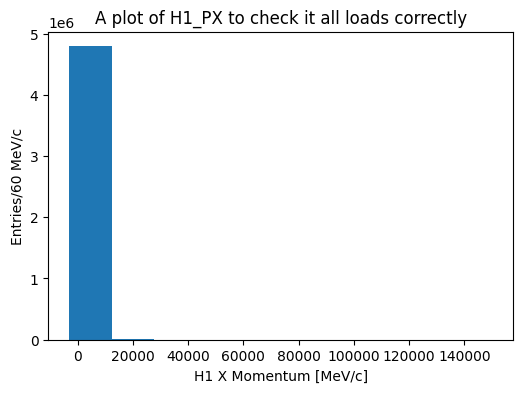

In [ ]:
# now our data is an array - we can plot it :)

plt.figure(figsize=(6, 4))


#play with the variables below ...
plt.hist(
    px,
    bins=10,
    range=(-3000, 150000),
    histtype="bar"
)

#Add some labels...

plt.xlabel("H1 X Momentum [MeV/c]")
plt.ylabel("Entries/60 MeV/c")
plt.title("A plot of H1_PX to check it all loads correctly")

plt.show()

This is the point at which the setup is all working - you can proceed below if you want to look at a basic guide to fitting functions to data using numpy etc.

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1451410097.py:44: SyntaxWarning: invalid escape sequence '\m'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
/tmp/ipython-input-1451410097.py:44: SyntaxWarning: invalid escape sequence '\s'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"


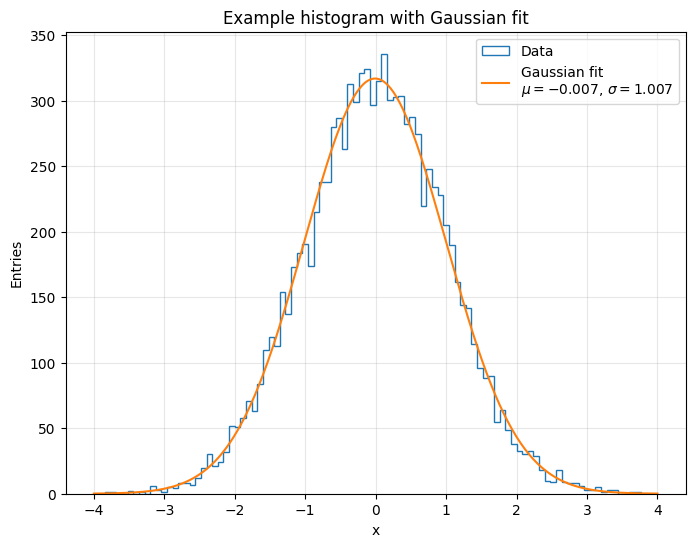

In [ ]:
# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -4, 4

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)

# ------------------------------------------------------------
# Now we perform a Gaussian fit
# ------------------------------------------------------------

# Fit a normal distribution to the data
# norm.fit returns the fitted mean and standard deviation
fit_mu, fit_sigma = norm.fit(data)

# Create x values for drawing the fitted function
x = np.linspace(x_min, x_max, 400)

# Evaluate the fitted Gaussian probability density function
pdf = norm.pdf(x, fit_mu, fit_sigma)

# Convert PDF to expected histogram counts
# (ROOT does this internally; here we scale manually)
bin_width = (x_max - x_min) / n_bins
fit_y = pdf * n_entries * bin_width


# ------------------------------------------------------------
# Draw the fitted Gaussian on top of the histogram
# ------------------------------------------------------------

ax.plot(
    x,
    fit_y,
    label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
)


# ------------------------------------------------------------
# abels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram with Gaussian fit")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot (equivalent to c.Draw())
plt.show()

## If you are **Here** - and Chris did not make the introduction yet - it's time for a coffee - take a break and wait for instructions about how to proceed.

#Why are we here?

This week is about finding out something about one of the fundemental questions in physics. Why do we have "stuff".

According to many of our models, and according to many measurements in particle physics, matter and anti-matter appear to be produced in equal quantities.

However, when one looks at the Universe in general, we have more matter than anti-matter left - so there need to be some processes where anti-matter and matter are not produced equally. You can find out more about the Matter/Anti-Matter Asymmetry [here](http://press.web.cern.ch/backgrounders/matterantimatter-asymmetry)

One place we look for this asymetry is in [charge-partity (CP) violation](https://www.symmetrymagazine.org/article/october-2005/explain-it-in-60-seconds) in particle physics processes. This essentially says that the processes that happen in the anti-particle version of a decay do not **exactly** match to the processes that happen in the particle version of the decay.



---



At LHCb, we produce both particle of the  B<sup>+</sup> meson and it's antiparticle the B<sup>-</sup> meson.

We cannot detect these mesons directly. They decay into other things before we have a chance to measure them properly. So we collect data on the decay products, often called daughter particles. There are 524 [documented](http://pdg.lbl.gov/2014/listings/rpp2014-list-B-plus-minus.pdf) ways that the B<sup>+/-</sup> decays into various combinations. In order to simplify the process, we choose decay combinations that are convenient or have particular properties.

In this analysis, we will take the process:-

B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>


To do so, we are given the following data for each event in our system:-

![alt text](https://raw.githubusercontent.com/lhcb/opendata-project/80d64a3796e593fc8f9b257e85f32ae2e54f131f/Images/Variables.png)

Here, H1 is the detected daughter particle (so a Kaon or a Pion), **not** the B-meson - the mother particle. Normally we would have to do some reconstruction from the decay products (the Daughters) to the Mother to be able to make some conclusions.

Let's get started with working with this data:

For our analysis, the momentum of each of the daughter particles is split into the three cartesian components. We have combined these into a variable called H1_Ptot

In [10]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Open the ROOT file
file = uproot.open("/content/LHCb_Data/B2HHH_MagnetDown.root")
tree = file["DecayTree"]

# List all available branches (variables)
print("Available variables in the tree:")
print(tree.keys())

# Load the main variables we'll need
# Daughter particle momenta components
h1_px = tree["H1_PX"].array(library="np")
h1_py = tree["H1_PY"].array(library="np")
h1_pz = tree["H1_PZ"].array(library="np")

h2_px = tree["H2_PX"].array(library="np")
h2_py = tree["H2_PY"].array(library="np")
h2_pz = tree["H2_PZ"].array(library="np")

h3_px = tree["H3_PX"].array(library="np")
h3_py = tree["H3_PY"].array(library="np")
h3_pz = tree["H3_PZ"].array(library="np")

# Particle identification variables
h1_probk = tree["H1_ProbK"].array(library="np")
h1_probpi = tree["H1_ProbPi"].array(library="np")
h2_probk = tree["H2_ProbK"].array(library="np")
h2_probpi = tree["H2_ProbPi"].array(library="np")
h3_probk = tree["H3_ProbK"].array(library="np")
h3_probpi = tree["H3_ProbPi"].array(library="np")

# Charges
h1_charge = tree["H1_Charge"].array(library="np")
h2_charge = tree["H2_Charge"].array(library="np")
h3_charge = tree["H3_Charge"].array(library="np")

Available variables in the tree:
['B_FlightDistance', 'B_VertexChi2', 'H1_PX', 'H1_PY', 'H1_PZ', 'H1_ProbK', 'H1_ProbPi', 'H1_Charge', 'H1_IPChi2', 'H1_isMuon', 'H2_PX', 'H2_PY', 'H2_PZ', 'H2_ProbK', 'H2_ProbPi', 'H2_Charge', 'H2_IPChi2', 'H2_isMuon', 'H3_PX', 'H3_PY', 'H3_PZ', 'H3_ProbK', 'H3_ProbPi', 'H3_Charge', 'H3_IPChi2', 'H3_isMuon']


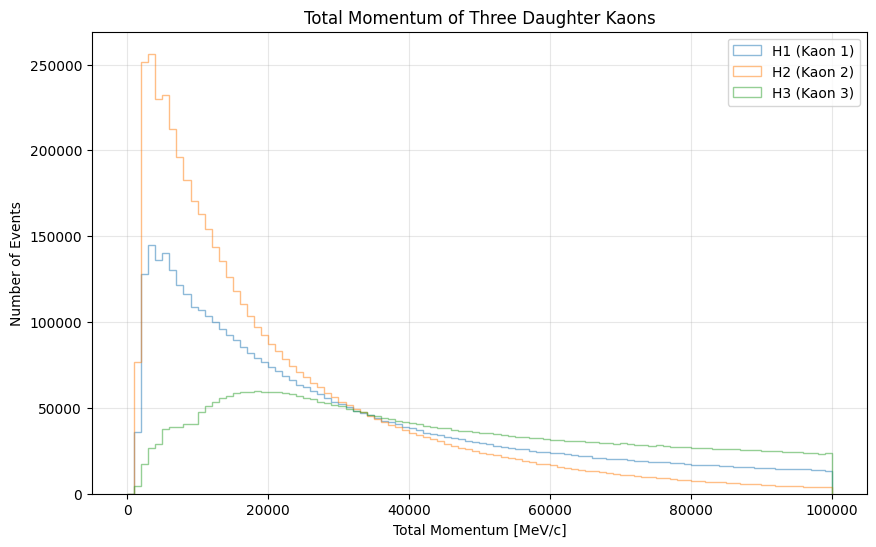

In [11]:
# Calculate total momentum for each daughter particle: Ptot = sqrt(PX² + PY² + PZ²)
h1_ptot = np.sqrt(h1_px**2 + h1_py**2 + h1_pz**2)
h2_ptot = np.sqrt(h2_px**2 + h2_py**2 + h2_pz**2)
h3_ptot = np.sqrt(h3_px**2 + h3_py**2 + h3_pz**2)

# Plot total momentum of all three daughters on one plot
plt.figure(figsize=(10, 6))

# Create histogram for each daughter
plt.hist(h1_ptot, bins=100, range=(0, 100000), alpha=0.5, label='H1 (Kaon 1)', histtype='step')
plt.hist(h2_ptot, bins=100, range=(0, 100000), alpha=0.5, label='H2 (Kaon 2)', histtype='step')
plt.hist(h3_ptot, bins=100, range=(0, 100000), alpha=0.5, label='H3 (Kaon 3)', histtype='step')

plt.xlabel('Total Momentum [MeV/c]')
plt.ylabel('Number of Events')
plt.title('Total Momentum of Three Daughter Kaons')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Now plot the total momentum for the mother (M_Ptot) this about how to calculate this from the information available

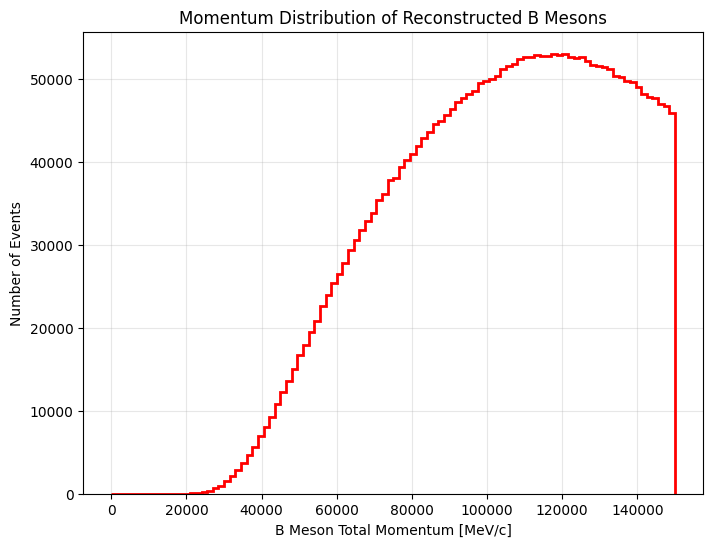

In [15]:
# Calculate mother particle (B meson) momentum
# B momentum = sum of daughter momenta (vector sum)
m_px = h1_px + h2_px + h3_px
m_py = h1_py + h2_py + h3_py
m_pz = h1_pz + h2_pz + h3_pz

# Calculate total momentum magnitude
m_ptot = np.sqrt(m_px**2 + m_py**2 + m_pz**2)

# Plot mother momentum
plt.figure(figsize=(8, 6))
plt.hist(m_ptot, bins=100, range=(0, 150000), histtype='step', color='red', linewidth=2)
plt.xlabel('B Meson Total Momentum [MeV/c]')
plt.ylabel('Number of Events')
plt.title('Momentum Distribution of Reconstructed B Mesons')
plt.grid(alpha=0.3)
plt.show()

Let's take a look at the whole data file that is available to us by looking at one specific entry - for example the number 45th entry in your array...

In [16]:
# Display the 45th entry (index 44 since Python is 0-indexed)
event_index = 44

# Create a dictionary with variable names and values
event_data = {
    'Variable': [
        'H1_PX', 'H1_PY', 'H1_PZ', 'H1_Ptot',
        'H2_PX', 'H2_PY', 'H2_PZ', 'H2_Ptot',
        'H3_PX', 'H3_PY', 'H3_PZ', 'H3_Ptot',
        'H1_ProbK', 'H1_ProbPi', 'H1_Charge',
        'H2_ProbK', 'H2_ProbPi', 'H2_Charge',
        'H3_ProbK', 'H3_ProbPi', 'H3_Charge',
        'M_PX', 'M_PY', 'M_PZ', 'M_Ptot'
    ],
    'Value': [
        h1_px[event_index], h1_py[event_index], h1_pz[event_index], h1_ptot[event_index],
        h2_px[event_index], h2_py[event_index], h2_pz[event_index], h2_ptot[event_index],
        h3_px[event_index], h3_py[event_index], h3_pz[event_index], h3_ptot[event_index],
        h1_probk[event_index], h1_probpi[event_index], h1_charge[event_index],
        h2_probk[event_index], h2_probpi[event_index], h2_charge[event_index],
        h3_probk[event_index], h3_probpi[event_index], h3_charge[event_index],
        m_px[event_index], m_py[event_index], m_pz[event_index], m_ptot[event_index]
    ]
}

# Convert to DataFrame for nice display
df_event = pd.DataFrame(event_data)
print(f"Data for event #{event_index + 1}:")
print(df_event.to_string(index=False))

Data for event #45:
 Variable        Value
    H1_PX -1634.778091
    H1_PY   838.662567
    H1_PZ 15416.880380
  H1_Ptot 15525.980000
    H2_PX -3456.159439
    H2_PY  -328.792523
    H2_PZ 21752.773752
  H2_Ptot 22028.080000
    H3_PX -2892.828671
    H3_PY -2105.696831
    H3_PZ 52930.481698
  H3_Ptot 53051.280000
 H1_ProbK     0.002000
H1_ProbPi     0.949091
H1_Charge     1.000000
 H2_ProbK     0.003451
H2_ProbPi     0.923865
H2_Charge    -1.000000
 H3_ProbK     0.968910
H3_ProbPi     0.083907
H3_Charge    -1.000000
     M_PX -7983.766201
     M_PY -1595.826787
     M_PZ 90100.135830
   M_Ptot 90467.240825


We have now completed the initial steps and begun to work through what we need to with the data. This is a perfect moment to take a coffee!

Having discovered all of the relevant information about our daughter particles, we need to combine the measurements about them into a single mother - which will be our B<sup>+</sup> or our B<sup>-</sup>

Having found our momentum and energy, we can use these quantities to find our experimental mass (not the theoretical mass as we have used for the reconstruction).

When we calculate this, we will get a distribution of masses. This is due to errors in the measurements made either by the detector, or in the experiment itself. We hope to have a reasonably narrow peak to work with, but, sometimes this is not possible.

Additionally there will be other particles in the detector - which means our daughters might have come from two or even three different processes. Events which don't come from the same process will give a higher or lower mass than we are looking for. This is typically called the *background* while events which come from our event of interest are called the *signal*

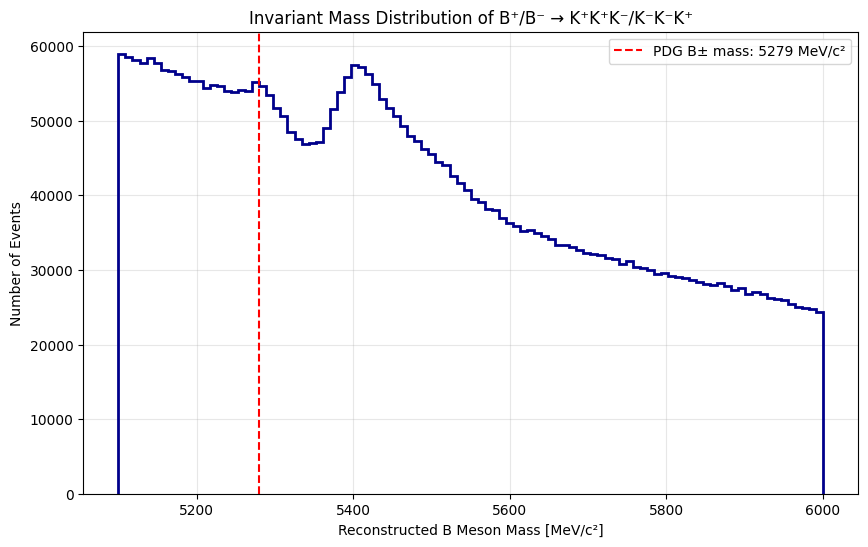

Number of events: 5135823
Mean reconstructed B mass: 5537.4 MeV/c²
Std dev of reconstructed B mass: 337.6 MeV/c²


In [39]:
# Calculate energy of each daughter particle
# For kaons: E = sqrt(p² + m²), where m_kaon = 493.677 MeV/c² (K± mass)
kaon_mass = 493.677  # MeV/c²

# Energy for each kaon
h1_energy = np.sqrt(h1_ptot**2 + kaon_mass**2)
h2_energy = np.sqrt(h2_ptot**2 + kaon_mass**2)
h3_energy = np.sqrt(h3_ptot**2 + kaon_mass**2)

# Total energy of the system
total_energy = h1_energy + h2_energy + h3_energy

# Reconstructed B meson mass using invariant mass formula:
# M² = E_total² - P_total²
b_mass_squared = total_energy**2 - m_ptot**2
b_mass = np.sqrt(np.maximum(b_mass_squared, 0))  # Ensure positive

# Plot the reconstructed B mass
plt.figure(figsize=(10, 6))
plt.hist(b_mass, bins=100, range=(5100, 6000), histtype='step', linewidth=2, color='darkblue')
plt.xlabel('Reconstructed B Meson Mass [MeV/c²]')
plt.ylabel('Number of Events')
plt.title('Invariant Mass Distribution of B⁺/B⁻ → K⁺K⁺K⁻/K⁻K⁻K⁺')
plt.axvline(5279, color='red', linestyle='--', label='PDG B± mass: 5279 MeV/c²')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Print some statistics
print(f"Number of events: {len(b_mass)}")
print(f"Mean reconstructed B mass: {np.mean(b_mass):.1f} MeV/c²")
print(f"Std dev of reconstructed B mass: {np.std(b_mass):.1f} MeV/c²")

We know that some of our particles are the B+ and some are the B- particle. There will also be some particles in our system that are not coming from a genuine B+/- or are a B+/- but are not constructed from Kaons.

We have some tools available to help:-

  *  During detection, software attributes the probability of a particle being a Kaon or a Pion (in the H1_ProbK or H1_ProbPi variable)
  * The detector also knows if the particle was a Muon - since it has detectors specifically for these. So it can attribute a 0 or a 1 to this probability
  * The reconstructed vertex has a some kind of quality associated with it (we call this the Vertex χ2 (this is the variable B_VertexChi2). This is the statistical measure that determines how well we found a single point to be the source of all three particles.



In order to get a better result, we should select our data to have the properties we desire and make some rules (often called a selection) to cut away data we don't want to include for various reasons. e.g. we know we don't have any muons in our decay - so any time H1/H2/H3 are a muon they should be excluded. The other variables are not so clear - so we can plot them to make a decision.

<Figure size 1200x800 with 0 Axes>

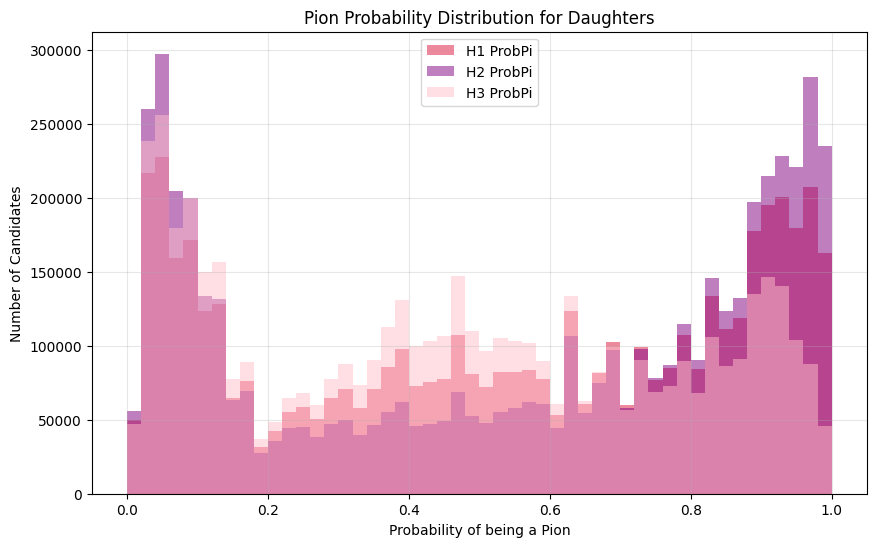

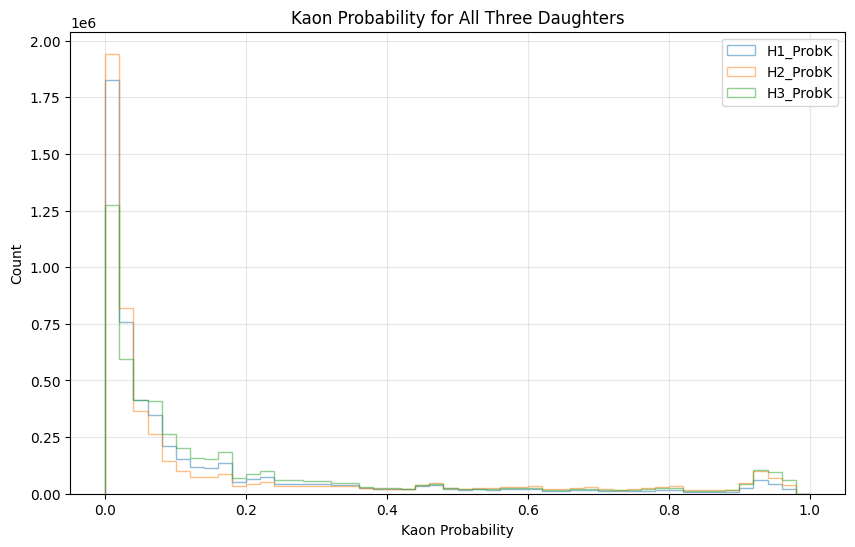

In [42]:
# Plot Kaon probabilities for all three daughters
plt.figure(figsize=(12, 8))


"""
Plotting
"""
plt.figure(figsize=(10, 6))

plt.hist(prob_pi_h1, bins=50, range=(0, 1), alpha=0.5, label='H1 ProbPi', color='crimson')
plt.hist(prob_pi_h2, bins=50, range=(0, 1), alpha=0.5, label='H2 ProbPi', color='purple')
plt.hist(prob_pi_h3, bins=50, range=(0, 1), alpha=0.5, label='H3 ProbPi', color='pink')

plt.title("Pion Probability Distribution for Daughters")
plt.xlabel("Probability of being a Pion")
plt.ylabel("Number of Candidates")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# Also plot all three on one plot for comparison
plt.figure(figsize=(10, 6))
plt.hist(h1_probk, bins=50, range=(0, 1), alpha=0.5, label='H1_ProbK', histtype='step')
plt.hist(h2_probk, bins=50, range=(0, 1), alpha=0.5, label='H2_ProbK', histtype='step')
plt.hist(h3_probk, bins=50, range=(0, 1), alpha=0.5, label='H3_ProbK', histtype='step')
plt.xlabel('Kaon Probability')
plt.ylabel('Count')
plt.title('Kaon Probability for All Three Daughters')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

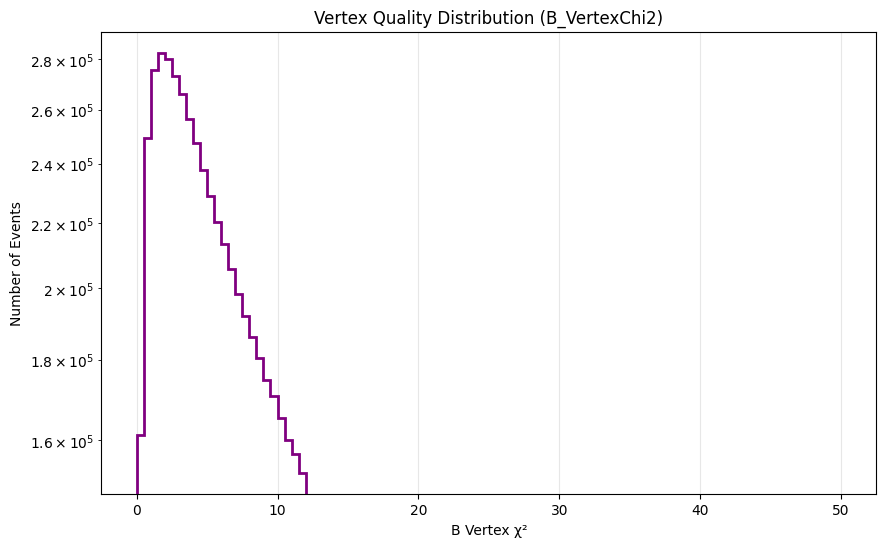

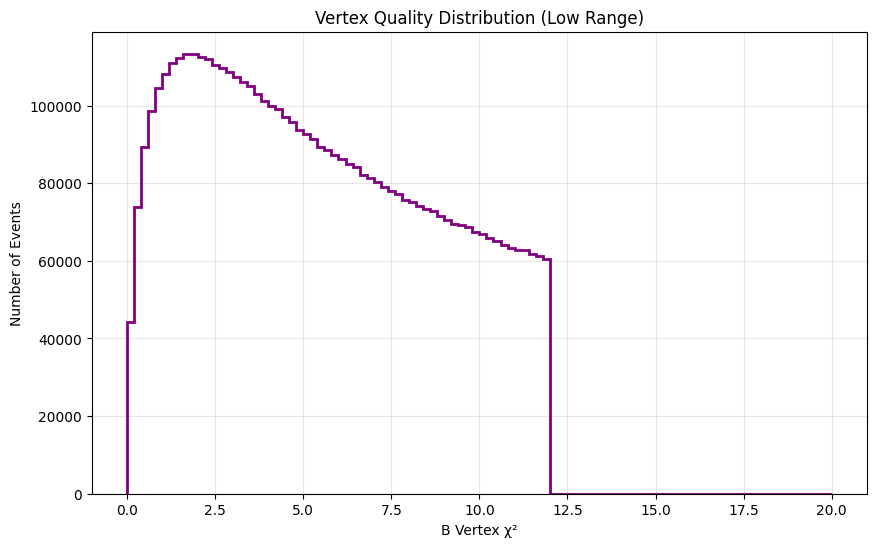

In [19]:
# Load B vertex chi² if not already loaded
b_vertex_chi2 = tree["B_VertexChi2"].array(library="np")

# Plot B vertex chi²
plt.figure(figsize=(10, 6))
plt.hist(b_vertex_chi2, bins=100, range=(0, 50), histtype='step', color='purple', linewidth=2)
plt.xlabel('B Vertex χ²')
plt.ylabel('Number of Events')
plt.title('Vertex Quality Distribution (B_VertexChi2)')
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

# Also show a linear scale version for low values
plt.figure(figsize=(10, 6))
plt.hist(b_vertex_chi2, bins=100, range=(0, 20), histtype='step', color='purple', linewidth=2)
plt.xlabel('B Vertex χ²')
plt.ylabel('Number of Events')
plt.title('Vertex Quality Distribution (Low Range)')
plt.grid(alpha=0.3)
plt.show()

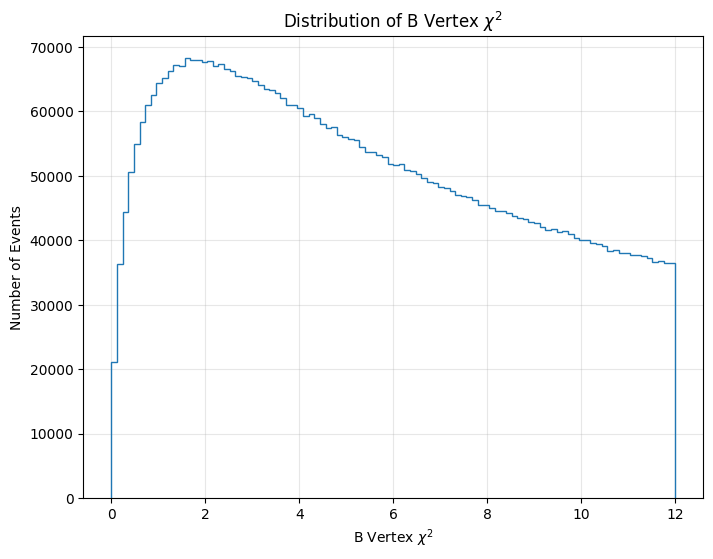

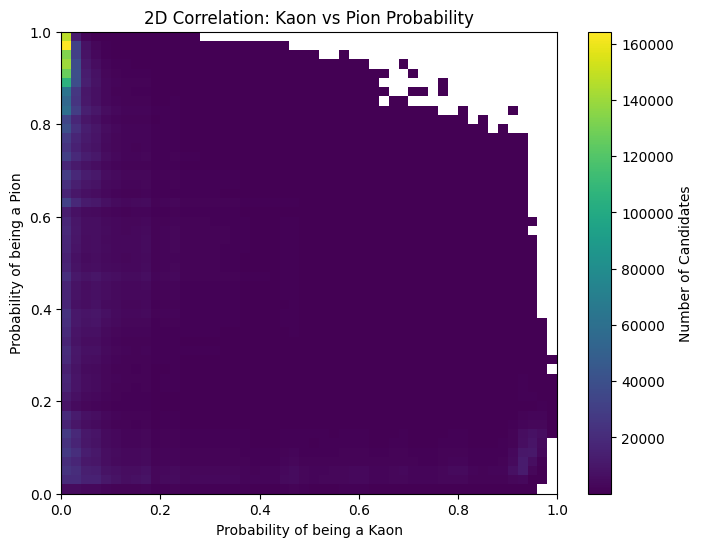

In [52]:
# Plot B_VertexChi2 for all B candidates

plt.figure(figsize=(8,6))

plt.hist(b_vertex_chi2, bins=100, histtype='step')

plt.xlabel(r'B Vertex $\chi^2$')
plt.ylabel('Number of Events')
plt.title(r'Distribution of B Vertex $\chi^2$')

plt.grid(alpha=0.3)
plt.show()

# 2D plot: Kaon vs Pion Probability (H1)

x_var = h1_probk
y_var = h1_probpi

plt.figure(figsize=(8, 6))

plt.hist2d(
    x_var,
    y_var,
    bins=50,
    range=[[0, 1], [0, 1]],
    cmin=1
)

plt.colorbar(label='Number of Candidates')

plt.title("2D Correlation: Kaon vs Pion Probability")
plt.xlabel("Probability of being a Kaon")
plt.ylabel("Probability of being a Pion")

plt.show()

Using these plots, we can now make a preselection string. This is a text string that looks like

In [21]:
# First, let's see what muon variables are available
print("Looking for muon identification variables...")
all_keys = list(tree.keys())
muon_keys = [key for key in all_keys if 'muon' in key.lower() or 'isMuon' in key]
print("Muon-related variables:", muon_keys)


# Check if muon variables exist
if 'H1_isMuon' in tree.keys():
    h1_ismuon = tree["H1_isMuon"].array(library="np")
    h2_ismuon = tree["H2_isMuon"].array(library="np")
    h3_ismuon = tree["H3_isMuon"].array(library="np")


    selection_mask = (
        (h1_probk > 0.5) & (h2_probk > 0.5) & (h3_probk > 0.5) &  # Good kaon ID
        (h1_ismuon == 0) & (h2_ismuon == 0) & (h3_ismuon == 0) &  # Not muons
        (b_vertex_chi2 < 20)  # Good vertex quality
    )
else:
    # If muon variables don't exist, use just kaon probability and vertex
    selection_mask = (
        (h1_probk > 0.5) & (h2_probk > 0.5) & (h3_probk > 0.5) &  # Good kaon ID
        (b_vertex_chi2 < 20)  # Good vertex quality
    )

# Count events before and after cuts
n_total = len(h1_probk)
n_selected = np.sum(selection_mask)

print(f"Total events: {n_total}")
print(f"Selected events: {n_selected}")
print(f"Events removed: {n_total - n_selected}")
print(f"Selection efficiency: {100*n_selected/n_total:.1f}%")
print(f"Events kept: {100*n_selected/n_total:.1f}% of original")

# Apply cuts to get selected data
h1_ptot_selected = h1_ptot[selection_mask]
h2_ptot_selected = h2_ptot[selection_mask]
h3_ptot_selected = h3_ptot[selection_mask]
b_mass_selected = b_mass[selection_mask]
m_ptot_selected = m_ptot[selection_mask]

Looking for muon identification variables...
Muon-related variables: ['H1_isMuon', 'H2_isMuon', 'H3_isMuon']
Total events: 5135823
Selected events: 15985
Events removed: 5119838
Selection efficiency: 0.3%
Events kept: 0.3% of original


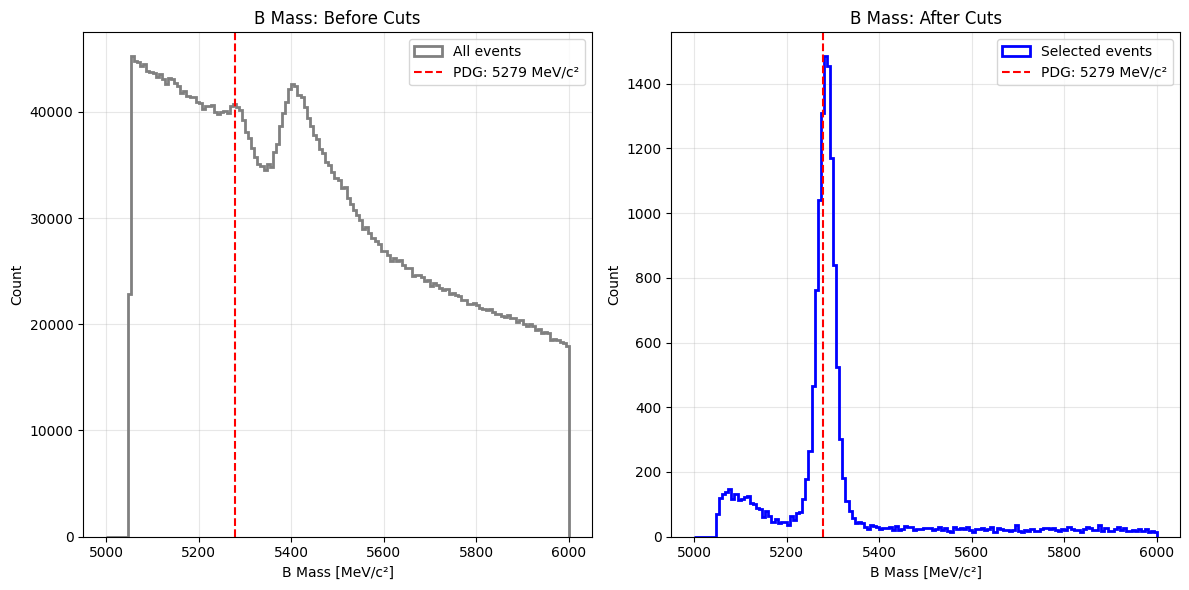

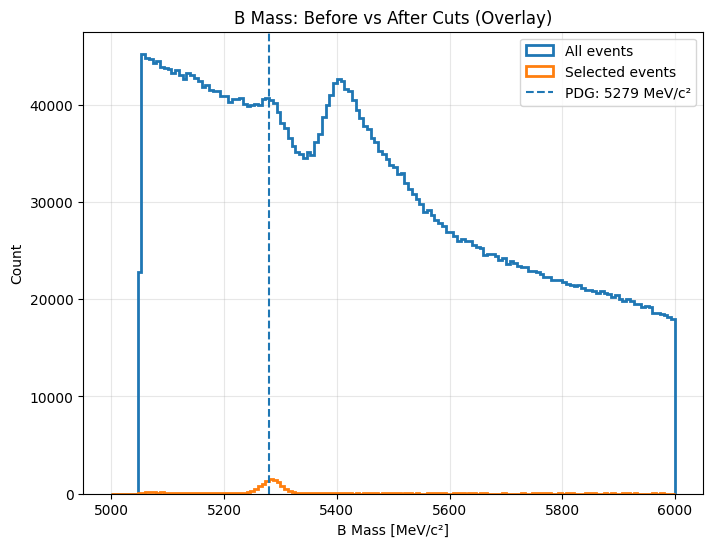

In [57]:
# Plot B mass before and after cuts
plt.figure(figsize=(12, 6))

# Before cuts (all data)
plt.subplot(1, 2, 1)
plt.hist(b_mass, bins=150, range=(5000, 6000), histtype='step',
         linewidth=2, color='gray', label='All events')
plt.xlabel('B Mass [MeV/c²]')
plt.ylabel('Count')
plt.title('B Mass: Before Cuts')
plt.axvline(5279, color='red', linestyle='--', label='PDG: 5279 MeV/c²')
plt.legend()
plt.grid(alpha=0.3)

# After cuts (selected data)
plt.subplot(1, 2, 2)
plt.hist(b_mass_selected, bins=150, range=(5000, 6000), histtype='step',
         linewidth=2, color='blue', label='Selected events')
plt.xlabel('B Mass [MeV/c²]')
plt.ylabel('Count')
plt.title('B Mass: After Cuts')
plt.axvline(5279, color='red', linestyle='--', label='PDG: 5279 MeV/c²')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Overlay: Before and After Cuts on the Same Plot

plt.figure(figsize=(8,6))

# Before cuts
plt.hist(
    b_mass,
    bins=150,
    range=(5000, 6000),
    histtype='step',
    linewidth=2,
    label='All events'
)

# After cuts
plt.hist(
    b_mass_selected,
    bins=150,
    range=(5000, 6000),
    histtype='step',
    linewidth=2,
    label='Selected events'
)

# PDG line
plt.axvline(5279, linestyle='--', label='PDG: 5279 MeV/c²')

plt.xlabel('B Mass [MeV/c²]')
plt.ylabel('Count')
plt.title('B Mass: Before vs After Cuts (Overlay)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [23]:
# Calculate signal purity metrics
# Define signal region (around B mass peak)
signal_region = (b_mass > 5200) & (b_mass < 5350)
sideband_region = ((b_mass > 5000) & (b_mass < 5150)) | ((b_mass > 5450) & (b_mass < 5600))

# Before cuts
n_signal_before = np.sum(signal_region)
n_sideband_before = np.sum(sideband_region)

# After cuts (need to create masks for selected events)
signal_region_selected = (b_mass_selected > 5200) & (b_mass_selected < 5350)
sideband_region_selected = ((b_mass_selected > 5000) & (b_mass_selected < 5150)) | \
                          ((b_mass_selected > 5450) & (b_mass_selected < 5600))

n_signal_after = np.sum(signal_region_selected)
n_sideband_after = np.sum(sideband_region_selected)

print("\n=== Signal Quality Metrics ===")
print(f"Before cuts:")
print(f"  Events in signal region (5200-5350 MeV): {n_signal_before}")
print(f"  Events in sidebands (5000-5150 & 5450-5600 MeV): {n_sideband_before}")
print(f"  S/B ratio in peak region: {n_signal_before/n_sideband_before:.2f}")

print(f"\nAfter cuts:")
print(f"  Events in signal region: {n_signal_after}")
print(f"  Events in sidebands: {n_sideband_after}")
print(f"  S/B ratio in peak region: {n_signal_after/n_sideband_after:.2f}")

# Calculate improvement
sb_ratio_before = n_signal_before / n_sideband_before if n_sideband_before > 0 else 0
sb_ratio_after = n_signal_after / n_sideband_after if n_sideband_after > 0 else 0

if sb_ratio_before > 0:
    improvement = 100 * (sb_ratio_after - sb_ratio_before) / sb_ratio_before
    print(f"\nImprovement in S/B ratio: {improvement:.1f}%")



=== Signal Quality Metrics ===
Before cuts:
  Events in signal region (5200-5350 MeV): 873832
  Events in sidebands (5000-5150 & 5450-5600 MeV): 1375559
  S/B ratio in peak region: 0.64

After cuts:
  Events in signal region: 10661
  Events in sidebands: 2310
  S/B ratio in peak region: 4.62

Improvement in S/B ratio: 626.5%


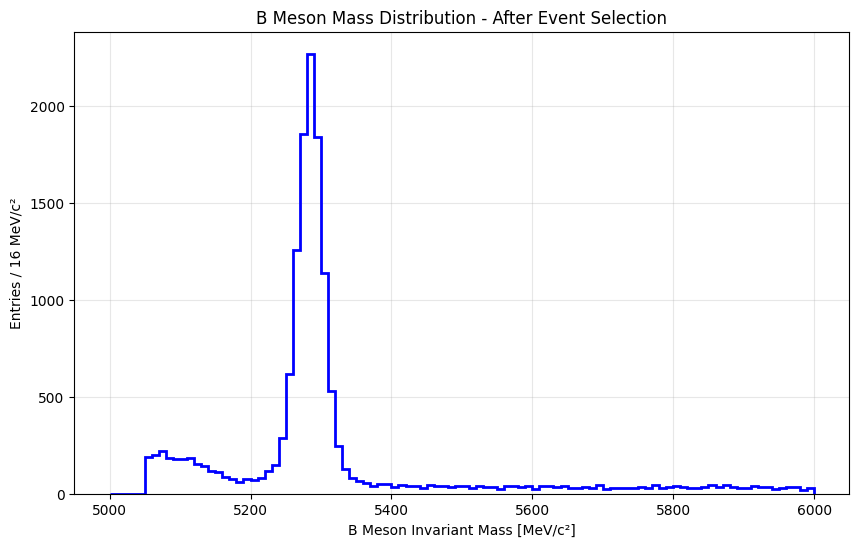

In [58]:
# Plot your selected data alone - simple and clean
plt.figure(figsize=(10, 6))

plt.hist(
    b_mass_selected,
    bins=100,
    range=(5000, 6000),
    histtype='step',
    color='blue',
    linewidth=2
)

plt.xlabel('B Meson Invariant Mass [MeV/c²]')
plt.ylabel('Entries / 16 MeV/c²')
plt.title('B Meson Mass Distribution - After Event Selection')
plt.grid(alpha=0.3)
plt.show()

#How do we count the number of events?

We now have a histogram of events that we have reconstructed as a B meson. But some of these events are caused by a co-incidence of events which would still occur if there were no B mesons actually produced. We call this the background. Background and signal are indistinguishable now as the detector cannot tell the difference and our cuts were unable to remove the events for physics reasons. We can do some statistical analysis, if we know the approximate shapes of our signal and our background. Just like a least-squares fitting we can run a fit routine to minimise the error between the fitted curve and our data. As an example, if we know our data has an exponential background and a gaussian signal:

![Gaussian+Exp Background](https://twiki.cern.ch/twiki/pub/RooStats/RooStatsTutorialsJune2013/GausExpModelFit.png)

Here the red line represents our signal, the blue dotted line is our background and the solid blue line is our combined curve. The graph also shows the number of signal events and the number of background events. The signal now is a tiny fraction of the total data shown in the plot.

In order to do this, we need to build a fit model, around which the software can try to fit our data.

We use RooFit for this, which includes:
* Gaussian
* Exponential
* Chebychev
* Crystal Ball
* Breit-Wigner

As well as several other choices.

Typically exponential and Chebychev functions are used for background and Gaussian, Crystal Ball and Breit-Wigner are used for signal. We can also combine them (e.g. 1 crystal ball, 1 gaussian, 1 exponential) in various ways.

In [30]:
# Probably handy to use a package like lmfit to help us with the models we might want to use, then use scipy to fit

!pip install lmfit

# check out its documentation for what shapes it can handle for you! https://pypi.org/project/lmfit/

# it can do the whole fitting story and output results too :)

[[Model]]
    (Model(gaussian, prefix='g_') + Model(constant, prefix='const_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 48
    # data points      = 80
    # variables        = 4
    chi-square         = 199.040573
    reduced chi-square = 2.61895491
    Akaike info crit   = 80.9185644
    Bayesian info crit = 90.4466709
    R-squared          = 0.99532799
[[Variables]]
    g_amplitude:  36305.2469 +/- 625.199419 (1.72%) (init = 5000)
    g_center:     5284.14821 +/- 0.32445952 (0.01%) (init = 5279)
    g_sigma:      18.3404686 +/- 0.26956835 (1.47%) (init = 30)
    const_c:      20.5070030 +/- 1.02596427 (5.00%) (init = 50)
    g_fwhm:       43.1885022 +/- 0.63478493 (1.47%) == '2.3548200*g_sigma'
    g_height:     789.712578 +/- 16.8705689 (2.14%) == '0.3989423*g_amplitude/max(1e-15, g_sigma)'
[[Correlations]] (unreported correlations are < 0.100)
    C(g_sigma, const_c)     = -0.2256
    C(g_amplitude, const_c) = -0.1783
    C(g_amplitude, g_sigma

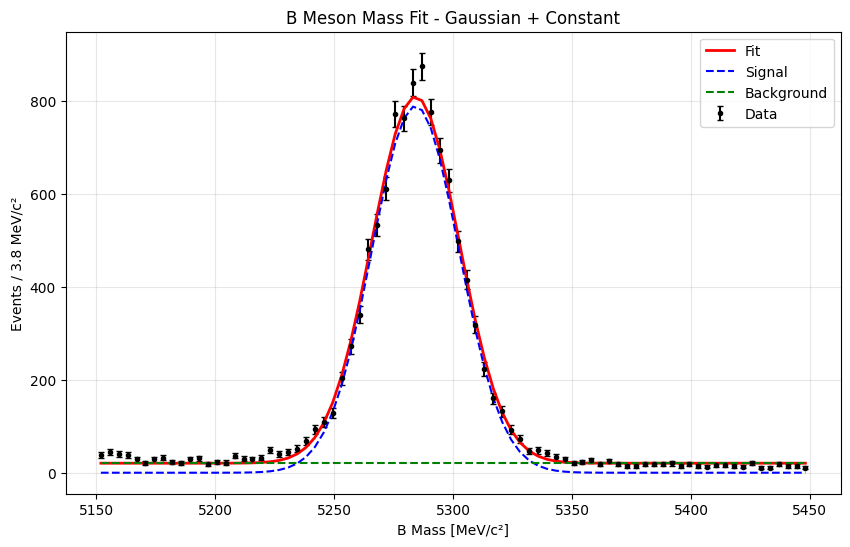


 SIGNAL YIELD: 36207 ± 625 events
 S/B ratio: 16.04


In [59]:
from lmfit.models import GaussianModel, ConstantModel
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# 1. Create histogram - focus on peak region
bins = 80
range_min, range_max = 5150, 5450

counts, bin_edges = np.histogram(b_mass_selected, bins=bins, range=(range_min, range_max))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# 2. Remove zero bins
mask = counts > 0
bin_centers_clean = bin_centers[mask]
counts_clean = counts[mask]
errors_clean = np.sqrt(counts_clean)
errors_clean = np.where(errors_clean == 0, 1, errors_clean)

# 3. Set up model
gauss = GaussianModel(prefix='g_')
constant = ConstantModel(prefix='const_')
model = gauss + constant

params = model.make_params()
params['g_center'].set(value=5279, min=5250, max=5300)
params['g_sigma'].set(value=30, min=10, max=80)
params['g_amplitude'].set(value=5000, min=100, max=50000)
params['const_c'].set(value=50, min=0, max=500)

# 4. Fit
result = model.fit(counts_clean, params, x=bin_centers_clean, weights=1/errors_clean)

# 5. Print results
print(result.fit_report())

# 6. Plot
plt.figure(figsize=(10, 6))
plt.errorbar(bin_centers_clean, counts_clean, yerr=errors_clean, fmt='ko', markersize=3, capsize=2, label='Data')
plt.plot(bin_centers_clean, result.best_fit, 'r-', linewidth=2, label='Fit')
comps = result.eval_components(x=bin_centers_clean)
plt.plot(bin_centers_clean, comps['g_'], 'b--', label='Signal')
plt.plot(bin_centers_clean, comps['const_'], 'g--', label='Background')
plt.xlabel('B Mass [MeV/c²]')
plt.ylabel(f'Events / {bin_width:.1f} MeV/c²')
plt.title('B Meson Mass Fit - Gaussian + Constant')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 7. Get signal yield
mu = result.params['g_center'].value
sigma = result.params['g_sigma'].value
amp = result.params['g_amplitude'].value

signal_yield, _ = quad(lambda x: amp * np.exp(-(x-mu)**2/(2*sigma**2))/(sigma*np.sqrt(2*np.pi)),
                       mu-3*sigma, mu+3*sigma)
background = result.params['const_c'].value * (6 * sigma)

print(f"\n SIGNAL YIELD: {signal_yield:.0f} ± {result.params['g_amplitude'].stderr:.0f} events")
print(f" S/B ratio: {signal_yield/background:.2f}")

Using this structure, you can in theory build whatever models you like!

Some recommendations (but not necessary to do all):-



*   Gauss+Exponential (as above)
*   Crystal Ball + Exponential
*   Gauss+Crystal Ball+Exponential (now you need to weigh the two signal peaks and then the total signal against total background)
*   Gauss+Chebychev
*   Two Crystal Balls + Exponential

So how good was the fit, and how many events do you have?

You can use the signal shape, the bin widths and the quad from scipy.integrate function to "count" how many events lie under your signal peak,  not including the background events - this is what we actually want.

It will also return to you an error - check in the scipy documentation about what that actually means....


              B MESON FIT RESULTS - SIGNAL YIELD EXTRACTION

FIT PARAMETERS:
----------------------------------------------------------------------
       Parameter  Value ± Error       Unit
      B Mass (μ) 5284.1     0.3     MeV/c²
       Width (σ)   18.3     0.3     MeV/c²
Signal Amplitude  36305     625     events
Background Level   20.5     1.0 events/MeV

SIGNAL YIELD (Events under Gaussian peak):
----------------------------------------------------------------------
Integration Range Signal Events ± Error Background S/B Ratio
      ±1σ (68.3%)         24785       0        752     32.95
      ±2σ (95.4%)         34653       0       1504     23.03
      ±3σ (99.7%)         36207       0       2257     16.04
       Full Range         36305       0          -         -

FIT QUALITY METRICS:
----------------------------------------------------------------------
            Metric   Value
                χ²   199.0
Degrees of Freedom      76
        Reduced χ²   2.619
           p-va

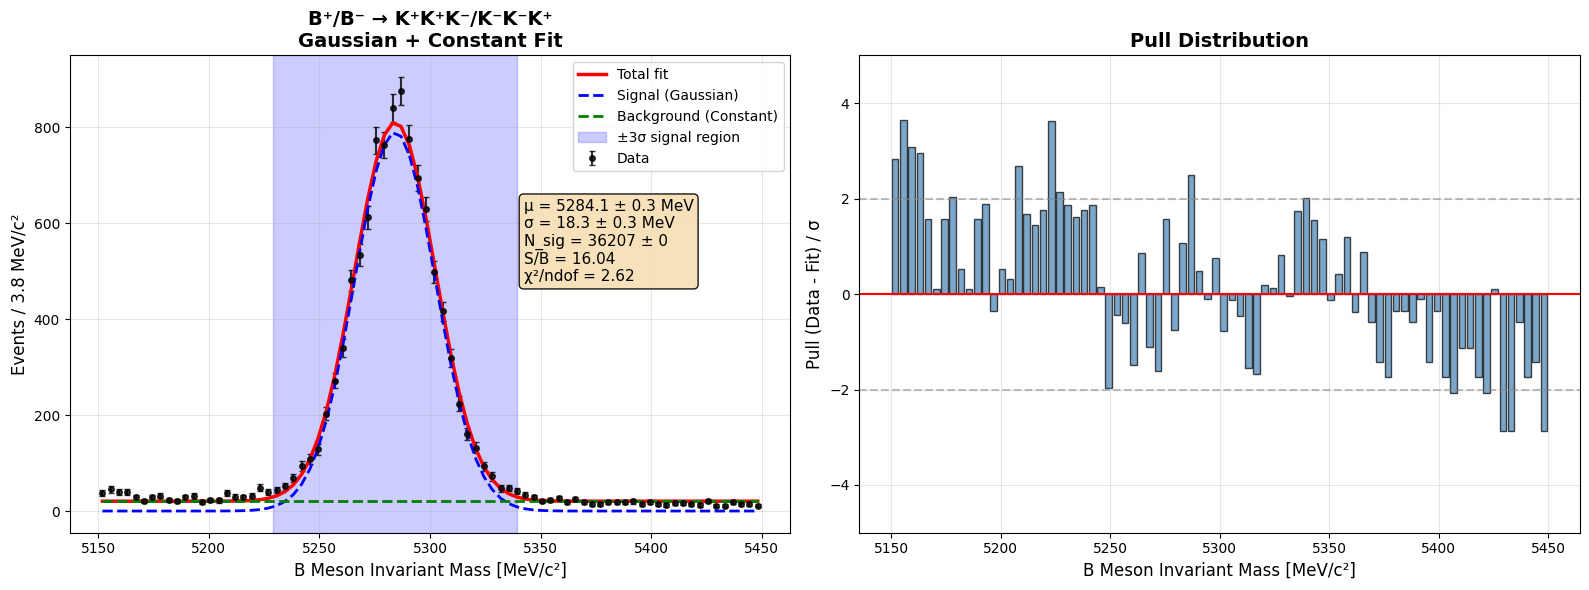


SIGNAL YIELD: 36207 ± 625 B meson events
S/B RATIO: 16.04
REDUCED χ²: 2.619


In [35]:
from lmfit.models import GaussianModel, ConstantModel
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import pandas as pd
from scipy.stats import chi2

bins = 80
range_min, range_max = 5150, 5450

counts, bin_edges = np.histogram(b_mass_selected, bins=bins, range=(range_min, range_max))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

mask = counts > 0
bin_centers_clean = bin_centers[mask]
counts_clean = counts[mask]
errors_clean = np.sqrt(counts_clean)
errors_clean = np.where(errors_clean == 0, 1, errors_clean)

gauss = GaussianModel(prefix='g_')
constant = ConstantModel(prefix='const_')
model = gauss + constant

params = model.make_params()
params['g_center'].set(value=5279, min=5250, max=5300)
params['g_sigma'].set(value=30, min=10, max=80)
params['g_amplitude'].set(value=5000, min=100, max=50000)
params['const_c'].set(value=50, min=0, max=500)

result = model.fit(counts_clean, params, x=bin_centers_clean, weights=1/errors_clean)

mu = result.params['g_center'].value
mu_err = result.params['g_center'].stderr
sigma = result.params['g_sigma'].value
sigma_err = result.params['g_sigma'].stderr
amplitude = result.params['g_amplitude'].value
amp_err = result.params['g_amplitude'].stderr
background_const = result.params['const_c'].value
bkg_err = result.params['const_c'].stderr

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

signal_total, signal_total_err = quad(
    lambda x: gaussian(x, amplitude, mu, sigma),
    range_min, range_max
)

signal_1sigma, signal_1sigma_err = quad(
    lambda x: gaussian(x, amplitude, mu, sigma),
    mu - 1*sigma, mu + 1*sigma
)

signal_2sigma, signal_2sigma_err = quad(
    lambda x: gaussian(x, amplitude, mu, sigma),
    mu - 2*sigma, mu + 2*sigma
)

signal_3sigma, signal_3sigma_err = quad(
    lambda x: gaussian(x, amplitude, mu, sigma),
    mu - 3*sigma, mu + 3*sigma
)

bkg_1sigma = background_const * (2 * sigma)
bkg_2sigma = background_const * (4 * sigma)
bkg_3sigma = background_const * (6 * sigma)

chi2_value = result.chisqr
ndof = result.nfree
reduced_chi2 = chi2_value / ndof
p_value = 1 - chi2.cdf(chi2_value, ndof)
significance_3sigma = signal_3sigma / np.sqrt(signal_3sigma + bkg_3sigma)

print("\n" + "="*70)
print("              B MESON FIT RESULTS - SIGNAL YIELD EXTRACTION")
print("="*70)

print("\nFIT PARAMETERS:")
print("-"*70)
fit_params_df = pd.DataFrame({
    'Parameter': ['B Mass (μ)', 'Width (σ)', 'Signal Amplitude', 'Background Level'],
    'Value': [f"{mu:.1f}", f"{sigma:.1f}", f"{amplitude:.0f}", f"{background_const:.1f}"],
    '± Error': [f"{mu_err:.1f}", f"{sigma_err:.1f}", f"{amp_err:.0f}", f"{bkg_err:.1f}"],
    'Unit': ['MeV/c²', 'MeV/c²', 'events', 'events/MeV']
})
print(fit_params_df.to_string(index=False))

print("\nSIGNAL YIELD (Events under Gaussian peak):")
print("-"*70)
signal_df = pd.DataFrame({
    'Integration Range': ['±1σ (68.3%)', '±2σ (95.4%)', '±3σ (99.7%)', 'Full Range'],
    'Signal Events': [f"{signal_1sigma:.0f}", f"{signal_2sigma:.0f}", f"{signal_3sigma:.0f}", f"{signal_total:.0f}"],
    '± Error': [f"{signal_1sigma_err:.0f}", f"{signal_2sigma_err:.0f}", f"{signal_3sigma_err:.0f}", f"{signal_total_err:.0f}"],
    'Background': [f"{bkg_1sigma:.0f}", f"{bkg_2sigma:.0f}", f"{bkg_3sigma:.0f}", '-'],
    'S/B Ratio': [f"{signal_1sigma/bkg_1sigma:.2f}", f"{signal_2sigma/bkg_2sigma:.2f}",
                  f"{signal_3sigma/bkg_3sigma:.2f}", '-']
})
print(signal_df.to_string(index=False))

print("\nFIT QUALITY METRICS:")
print("-"*70)
quality_df = pd.DataFrame({
    'Metric': ['χ²', 'Degrees of Freedom', 'Reduced χ²', 'p-value', 'Significance'],
    'Value': [f"{chi2_value:.1f}", f"{ndof}", f"{reduced_chi2:.3f}", f"{p_value:.4f}", f"{significance_3sigma:.1f} σ"]
})
print(quality_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comps = result.eval_components(x=bin_centers_clean)

ax1.errorbar(bin_centers_clean, counts_clean, yerr=errors_clean,
             fmt='ko', markersize=4, capsize=2, label='Data', alpha=0.8)
ax1.plot(bin_centers_clean, result.best_fit, 'r-', linewidth=2.5, label='Total fit')
ax1.plot(bin_centers_clean, comps['g_'], 'b--', linewidth=2, label='Signal (Gaussian)')
ax1.plot(bin_centers_clean, comps['const_'], 'g--', linewidth=2, label='Background (Constant)')

ax1.axvspan(mu - 3*sigma, mu + 3*sigma, alpha=0.2, color='blue', label='±3σ signal region')

ax1.set_xlabel('B Meson Invariant Mass [MeV/c²]', fontsize=12)
ax1.set_ylabel(f'Events / {bin_width:.1f} MeV/c²', fontsize=12)
ax1.set_title('B⁺/B⁻ → K⁺K⁺K⁻/K⁻K⁻K⁺\nGaussian + Constant Fit', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(alpha=0.3)

textstr = f'μ = {mu:.1f} ± {mu_err:.1f} MeV\n'
textstr += f'σ = {sigma:.1f} ± {sigma_err:.1f} MeV\n'
textstr += f'N_sig = {signal_3sigma:.0f} ± {signal_3sigma_err:.0f}\n'
textstr += f'S/B = {signal_3sigma/bkg_3sigma:.2f}\n'
textstr += f'χ²/ndof = {reduced_chi2:.2f}'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax1.text(0.63, 0.7, textstr, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)

residuals = (counts_clean - result.best_fit) / errors_clean
ax2.bar(bin_centers_clean, residuals, width=bin_width*0.8,
        color='steelblue', edgecolor='black', alpha=0.7)
ax2.axhline(y=0, color='red', linestyle='-', linewidth=1.5)
ax2.axhline(y=2, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=-2, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('B Meson Invariant Mass [MeV/c²]', fontsize=12)
ax2.set_ylabel('Pull (Data - Fit) / σ', fontsize=12)
ax2.set_title('Pull Distribution', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_ylim(-5, 5)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(f"SIGNAL YIELD: {signal_3sigma:.0f} ± {amp_err:.0f} B meson events")
print(f"S/B RATIO: {signal_3sigma/bkg_3sigma:.2f}")
print(f"REDUCED χ²: {reduced_chi2:.3f}")
print("="*70)

#Counting

So we have now loaded our data; we have reconstructed information about the mother B meson and we have cut away any data which looks like it might not be what we are looking for. We have then plotted histograms of the mass of the B meson and used this to fit a model, a function to describe the events there. We now have to identify which of our events belong to the B<sup>+</sup> and how many of them belong to B<sup>-</sup>.

To do this, should split out data into two groups (and throw away data which doesn't comply with either decay)

We will be looking for the events which are


B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>

We can look for the number of positive and negative charges in H1, H2 and H3 (using the variable ```H1_Charge``` etc.). If we have 0 or 3 positive charges, we should throw the event away and if we have 1 it should be assigned be a B<sup>-</sup>, with 2 it should be a B<sup>+</sup>

Once we have defined if it's a B<sup>+</sup> or a B <sup>-</sup>, we should go ahead and ensure the pre-selection is applied and then plot our B mass, and fit the model to find the yield.

We can then calculate the assymetry from this equation:

$A=\frac{(N^{B-}-N^{B+})}{(N^{B-}+N^{B+})}$

Where N<sup>B+/- </sup> is the number of events found from the fitted yield of the signal from each data set.

The uncertainty on this result is given by:

$\sigma_A=\sqrt\frac{1-A^2}{N^{B-}+N^{B+}}$

Calculate these two values for your data and print them below:

CHARGE SEPARATION RESULTS
Total events after cuts: 17102
B⁺ events (charge sum = +1): 8917
B⁻ events (charge sum = -1): 8185
Rejected events (charge sum = 0, +2, -2, +3, -3): 0

B⁺ sample size: 8917 events
B⁻ sample size: 8185 events

FITTING B⁺ AND B⁻...

CP ASYMMETRY RESULTS
   Events Signal Yield
B⁺   8917  26938 ± 590
B⁻   8185  24487 ± 601

ASYMMETRY CALCULATION
N(B⁻) = 24487 ± 601
N(B⁺) = 26938 ± 590
Total = 51425

A = (24487 - 26938) / (24487 + 26938)
A = -0.0477
σ_A = 0.0044

→ A = -0.0477 ± 0.0044


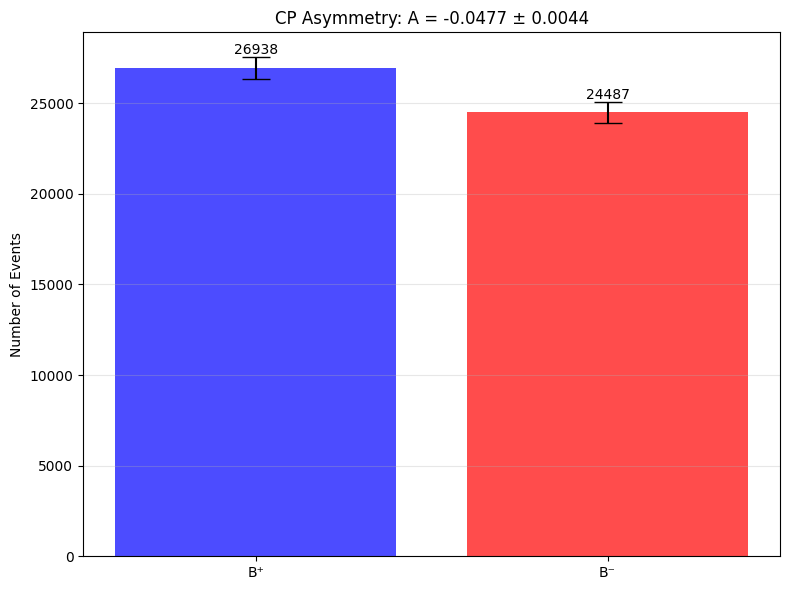


FINAL RESULT
A = -0.0477 ± 0.0044
This is 10.8σ from zero.


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, ConstantModel
from scipy.integrate import quad
import pandas as pd

h1_charge = tree["H1_Charge"].array(library="np")
h2_charge = tree["H2_Charge"].array(library="np")
h3_charge = tree["H3_Charge"].array(library="np")

total_charge = h1_charge + h2_charge + h3_charge

selection_mask = (
    (h1_probk > 0.5) & (h2_probk > 0.5) & (h3_probk > 0.5) &
    (b_vertex_chi2 < 20)
)

# FIXED: B⁺ has total charge = +1 (K⁺K⁺K⁻ = +1+1-1 = +1)
# B⁻ has total charge = -1 (K⁻K⁻K⁺ = -1-1+1 = -1)
bplus_mask = selection_mask & (total_charge == 1)
bminus_mask = selection_mask & (total_charge == -1)

print("="*70)
print("CHARGE SEPARATION RESULTS")
print("="*70)
print(f"Total events after cuts: {np.sum(selection_mask)}")
print(f"B⁺ events (charge sum = +1): {np.sum(bplus_mask)}")
print(f"B⁻ events (charge sum = -1): {np.sum(bminus_mask)}")
print(f"Rejected events (charge sum = 0, +2, -2, +3, -3): {np.sum(selection_mask) - np.sum(bplus_mask) - np.sum(bminus_mask)}")
print("="*70)

b_mass_bplus = b_mass[bplus_mask]
b_mass_bminus = b_mass[bminus_mask]

print(f"\nB⁺ sample size: {len(b_mass_bplus)} events")
print(f"B⁻ sample size: {len(b_mass_bminus)} events")

# Only fit if there are events
if len(b_mass_bplus) == 0:
    print("\n⚠️  WARNING: No B⁺ events found! Check your charge selection.")
    print("Using raw counts instead of fitted yields for asymmetry calculation.")
    N_plus = np.sum(bplus_mask)
    N_minus = np.sum(bminus_mask)
    N_plus_err = np.sqrt(N_plus)
    N_minus_err = np.sqrt(N_minus)
else:
    def fit_b_mass(mass_data, particle_type):
        if len(mass_data) < 10:
            return None

        bins = 60
        range_min, range_max = 5150, 5450

        counts, bin_edges = np.histogram(mass_data, bins=bins, range=(range_min, range_max))
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]

        mask = counts > 0
        bin_centers_clean = bin_centers[mask]
        counts_clean = counts[mask]
        errors_clean = np.sqrt(counts_clean)
        errors_clean = np.where(errors_clean == 0, 1, errors_clean)

        gauss = GaussianModel(prefix='g_')
        constant = ConstantModel(prefix='const_')
        model = gauss + constant

        params = model.make_params()
        params['g_center'].set(value=5279, min=5250, max=5300)
        params['g_sigma'].set(value=30, min=10, max=80)
        params['g_amplitude'].set(value=len(mass_data)*0.5, min=100, max=50000)
        params['const_c'].set(value=10, min=0, max=500)

        result = model.fit(counts_clean, params, x=bin_centers_clean, weights=1/errors_clean)

        mu = result.params['g_center'].value
        mu_err = result.params['g_center'].stderr
        sigma = result.params['g_sigma'].value
        sigma_err = result.params['g_sigma'].stderr
        amplitude = result.params['g_amplitude'].value
        amp_err = result.params['g_amplitude'].stderr

        def gaussian(x, amp, mu, sigma):
            return amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

        signal_yield, _ = quad(
            lambda x: gaussian(x, amplitude, mu, sigma),
            mu - 3*sigma, mu + 3*sigma
        )

        return {
            'particle': particle_type,
            'signal_yield': signal_yield,
            'signal_error': amp_err,
            'mass': mu,
            'mass_err': mu_err,
            'width': sigma,
            'width_err': sigma_err,
            'chi2_ndof': result.chisqr/result.nfree,
            'result': result,
            'bin_centers': bin_centers_clean,
            'counts': counts_clean,
            'errors': errors_clean,
            'bin_width': bin_width
        }

    print("\nFITTING B⁺ AND B⁻...")
    bplus_fit = fit_b_mass(b_mass_bplus, "B⁺")
    bminus_fit = fit_b_mass(b_mass_bminus, "B⁻")

    N_plus = bplus_fit['signal_yield'] if bplus_fit else len(b_mass_bplus)
    N_minus = bminus_fit['signal_yield'] if bminus_fit else len(b_mass_bminus)
    N_plus_err = bplus_fit['signal_error'] if bplus_fit else np.sqrt(len(b_mass_bplus))
    N_minus_err = bminus_fit['signal_error'] if bminus_fit else np.sqrt(len(b_mass_bminus))

# Calculate asymmetry
A = (N_minus - N_plus) / (N_minus + N_plus)
A_err = np.sqrt((1 - A**2) / (N_minus + N_plus))

print("\n" + "="*70)
print("CP ASYMMETRY RESULTS")
print("="*70)

results_df = pd.DataFrame({
    '': ['B⁺', 'B⁻'],
    'Events': [f"{np.sum(bplus_mask)}", f"{np.sum(bminus_mask)}"],
    'Signal Yield': [f"{N_plus:.0f} ± {N_plus_err:.0f}", f"{N_minus:.0f} ± {N_minus_err:.0f}"],
})
print(results_df.to_string(index=False))

print("\n" + "="*70)
print("ASYMMETRY CALCULATION")
print("="*70)
print(f"N(B⁻) = {N_minus:.0f} ± {N_minus_err:.0f}")
print(f"N(B⁺) = {N_plus:.0f} ± {N_plus_err:.0f}")
print(f"Total = {N_minus + N_plus:.0f}")
print(f"\nA = ({N_minus:.0f} - {N_plus:.0f}) / ({N_minus:.0f} + {N_plus:.0f})")
print(f"A = {A:.4f}")
print(f"σ_A = {A_err:.4f}")
print(f"\n→ A = {A:.4f} ± {A_err:.4f}")
print("="*70)

# Simple bar plot
fig, ax = plt.subplots(figsize=(8, 6))
labels = ['B⁺', 'B⁻']
yields = [N_plus, N_minus]
yerrs = [N_plus_err, N_minus_err]

bars = ax.bar(labels, yields, yerr=yerrs, capsize=10, color=['blue', 'red'], alpha=0.7)
ax.set_ylabel('Number of Events')
ax.set_title(f'CP Asymmetry: A = {A:.4f} ± {A_err:.4f}')
ax.grid(alpha=0.3, axis='y')

for bar, val in zip(bars, yields):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(yerrs),
            f'{val:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FINAL RESULT")
print("="*70)
print(f"A = {A:.4f} ± {A_err:.4f}")
print(f"This is {abs(A)/A_err:.1f}σ from zero.")
print("="*70)

#Congratulations!

You just made your first LHCb physics analysis. Does this seem like a reasonable result? Did we explain why we have an excess of mass in the Universe?

## **Bonus content only below here:**

To make a further anaysis, we can look into the intermediate processes.

We have so far considered only that the B meson ultimately decays into three kaons. It may be that on the way, the B meson first decays into a Kaon and another particle, and then from that particle to two Kaons.

We would expect this to be one of three possible modes (for B<sup>+</sup>):

$R^{++} \rightarrow K_1^+ +K_2^+$

(we don't expect this to happen because of the like charges in the Kaons)

$R^0 \rightarrow K_1^+ +K_3^-$

$R^0 \rightarrow K_2^+ +K_3^-$

(Expect symmetric arrangements for B<sup>-</sup>)

To analyse the intermediate states we can measure the invarient masses of the intermediate states and then plot them on what is called a Dalitz plot (this is a 2D plot with two different two body decays (from the three body decay) on each axis)

![Dalitz Plot](https://slideplayer.com/slide/15960097/88/images/15/Dalitz+plot%3A+%CE%9B+c+%2B+%E2%86%92%F0%9D%91%9D+%F0%9D%90%BE+%E2%88%92+%F0%9D%9C%8B+%2B.jpg)


In [ ]:
#Define a function to find the invarient mass of two given Kaons

In [ ]:
#Then, ensuring you're still taking the data after the selection, make a Dalitz plot. This is a 2-D scatter plot (use e.g. TH2F to make the plot where we used TH1F before)
#Choose an appropriate binning in your scatter

We can further improve our plot, since two sets of particles on each axis are exactly the same (one positive Kaon, one negative Kaon). So we can plot the maximum of the two values on one axis and the minimum on the other. We can use a quick numpy check and then plot those values.

In [ ]:
#Make the revised Dalitz plot here for B+ mesons

In [ ]:
#Make the revised Dalitz plot here for B- mesons

In [ ]:
#Where we have a higher density of points (or a bigger value in the bin) this is indication of an intermediate resonance
#Check out the possible resonances you have found in the PDG (http://pdg.lbl.gov/2020/tables/contents_tables.html)